# Dashboard — Assistente de IA vs. codificação manual

Notebook de visualização do experimento (EPIC #43). Consolida, em um só lugar,
os dados, os testes estatísticos e **uma figura por questão de pesquisa**, cada
uma em um tipo de gráfico diferente:

| Seção | Questão | Gráfico | Status |
|---|---|---|---|
| 0–1 | Carga, dicionário, integridade, outliers | — | ✔ #44 · #48 |
| 2 | **RQ1** — tempo (*time-to-green*) | **violino** + box/pares | ✔ #45 · #49 |
| 3 | **RQ2** — defeitos / taxa de sucesso | **heatmap** + barras | ✔ #46 · #49 |
| 4 | **RQ3** — métricas estáticas | **box plot** (4 métricas) | ✔ #47 · #49 |
| 5 | **RQ4** — tempo × estrutura (RQ extra) | **dispersão + Pearson** | ✔ |
| 6 | **RQ5** — efeito por kata (diferencial) | **bolhas** | ✔ |
| 7 | Síntese para o Relatório Final | tabela-resumo | ✔ #50 |

Hipóteses, variáveis e testes planejados: [`docs/desenho-experimento.md`](../../docs/desenho-experimento.md).
Análises por RQ: [`docs/analise-rq1.md`](../../docs/analise-rq1.md) ·
[rq2](../../docs/analise-rq2.md) · [rq3](../../docs/analise-rq3.md) ·
[rq4](../../docs/analise-rq4.md) · [rq5](../../docs/analise-rq5.md).

**Execução:** `pip install -r scripts/dashboard/requirements.txt` e depois
*Run All*. O notebook é reprodutível a partir dos arquivos do repositório —
não há dado digitado aqui, e os números dos testes vêm dos JSON gerados pelos
scripts de `scripts/analysis/` (o notebook os executa se faltarem). As figuras
são renderizadas inline e exportadas em PNG para `results/figures/`, o mesmo
conjunto que `python scripts/dashboard/plots.py` e
`python scripts/dashboard/plots_advanced.py` geram sem abrir o notebook.

## 0. Carga dos dados (issue #48)

`build_dataset()` junta, pela tripla `(participant, kata, treatment)`:

- o dataset consolidado da issue #44 (`dados/consolidado.csv`), se existir;
- `results/timing.json` — tempo, censura e contagem de testes (RQ1/RQ2);
- `results/static_metrics.csv` — LOC, complexidade, duplicação, MI (RQ3).

In [1]:
import json
import subprocess
import sys
from pathlib import Path

import pandas as pd

# raiz do repo a partir da localizacao deste notebook (sem caminho absoluto)
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "scripts" / "dashboard" / "load_data.py").exists() \
        and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "scripts" / "dashboard"))

from load_data import (  # noqa: E402
    DATA_DICTIONARY,
    METRIC_COLUMNS,
    build_dataset,
    build_paired_frame,
    build_participant_summary,
    descriptives_by_treatment,
    describe_dataset,
    success_rate_by_treatment,
    validate_dataset,
)
from plots import (  # noqa: E402  (issue #49)
    RQ3_METRICS,
    export_all,
    figure_rq1,
    figure_rq2,
    figure_rq3_metric,
    figure_rq3_overview,
    save_figure,
)
from plots_advanced import (  # noqa: E402  (uma figura por RQ)
    figure_rq1_violin,
    figure_rq2_heatmap,
    figure_rq3_box,
    figure_rq4_scatter,
    figure_rq5_bubbles,
)

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)

FIG_DIR = REPO_ROOT / "results" / "figures"   # destino das figuras (issue #49)
FIG_DIR.mkdir(parents=True, exist_ok=True)


def resultados(rq: str) -> dict:
    """Le dados/<rq>_resultados.json, rodando scripts/analysis/<rq>.py se faltar.

    Os testes estatisticos vivem nos scripts de analise, nao no notebook: assim
    o numero que aparece aqui, no JSON, na figura e no relatorio e o mesmo, e um
    *Run All* em clone limpo continua funcionando.
    """
    path = REPO_ROOT / "dados" / f"{rq}_resultados.json"
    if not path.exists():
        script = REPO_ROOT / "scripts" / "analysis" / f"{rq}.py"
        print(f"{path.name} ausente; executando {script.name}...")
        subprocess.run([sys.executable, str(script)], check=True, cwd=REPO_ROOT)
    return json.loads(path.read_text(encoding="utf-8"))


df = build_dataset(repo_root=REPO_ROOT)
print("fontes:", df.attrs.get("sources"))
df.head(len(df))

fontes: {'consolidado': '/Users/rafaelfranco/Documents/Repositorys/Lab02AssistentesdeIAxCodManual/dados/consolidado.csv', 'timing': '/Users/rafaelfranco/Documents/Repositorys/Lab02AssistentesdeIAxCodManual/results/timing.json', 'static_metrics': '/Users/rafaelfranco/Documents/Repositorys/Lab02AssistentesdeIAxCodManual/results/static_metrics.csv'}


,trial_id,participant,kata,treatment,time_to_green_s,time_to_green_min,elapsed_s,elapsed_min,censored,event,status,timebox_s,timebox_min,tests_passed,tests_failed,tests_total,pct_tests_passing,success,files,loc,sloc,cc_avg,cc_total,mi_avg,duplication_pct,started_at,ended_at,recorded_at,collected_at,has_timing,has_metrics,notes,fonte_tempo,fonte_testes,no_plano_4_katas
0,paulo/kata1_manual,paulo,kata1,manual,24.000,0.4000,24.0,0.40,<NA>,<NA>,derived_from_reference,2100.0,35.0,12,0,12,100.0,<NA>,1,37,33,3.60,18.0,47.31,0.0,2026-09-17 02:10:49+00:00,2026-09-17 02:11:13+00:00,2026-09-23 22:50:31+00:00,2026-09-23 22:48:36+00:00,True,True,SEM IA - implementacao manual. Duracao calcula...,derivado_ou_autodeclarado,verificacao_posterior,True
1,paulo/kata2_manual,paulo,kata2,manual,496.998,8.2833,497.0,8.28,<NA>,<NA>,derived_from_reference,2100.0,35.0,10,0,10,100.0,<NA>,1,34,25,7.00,7.0,73.19,0.0,2026-09-17 02:42:23+00:00,2026-09-17 02:50:40+00:00,2026-09-23 22:50:31+00:00,2026-09-23 22:48:49+00:00,True,True,SEM IA - implementacao manual. Testes conferi...,derivado_ou_autodeclarado,verificacao_posterior,True
2,paulo/kata4_ai,paulo,kata4,ai,652.002,10.8667,652.0,10.87,<NA>,<NA>,derived_from_reference,2100.0,35.0,10,0,10,100.0,<NA>,1,64,17,2.50,5.0,71.07,0.0,2026-09-17 01:01:31+00:00,2026-09-17 01:12:23+00:00,2026-09-23 22:50:31+00:00,2026-09-23 22:48:56+00:00,True,True,COM IA - ChatGPT. Testes conferidos posterior...,derivado_ou_autodeclarado,verificacao_posterior,True
3,paulo/kata5_ai,paulo,kata5,ai,30.000,0.5000,30.0,0.50,<NA>,<NA>,derived_from_reference,2100.0,35.0,12,0,12,100.0,<NA>,1,74,22,2.50,10.0,72.48,0.0,2026-09-17 01:47:01+00:00,2026-09-17 01:47:31+00:00,2026-09-23 22:50:31+00:00,2026-09-23 22:49:03+00:00,True,True,COM IA - ChatGPT. Testes conferidos posterior...,derivado_ou_autodeclarado,verificacao_posterior,True
4,rafael/kata1_ai,rafael,kata1,ai,12.000,0.2000,12.0,0.20,False,1,green,2100.0,35.0,12,0,12,100.0,True,1,59,35,2.60,13.0,67.93,0.0,2026-09-17 02:10:55+00:00,2026-09-17 02:11:09+00:00,2026-09-17 02:11:09+00:00,2026-09-17 14:56:23+00:00,True,True,"COM IA - Claude Code (Opus 5), 1 prompt (issue...",cronometro_ou_reconstituido,registro_trial,True
5,rafael/kata2_manual,rafael,kata2,manual,487.000,8.1167,487.0,8.12,False,1,green,2100.0,35.0,10,0,10,100.0,True,1,33,28,8.00,8.0,62.94,0.0,2026-09-17 02:42:29+00:00,2026-09-17 02:50:36+00:00,2026-09-17 01:14:28+00:00,2026-09-17 14:56:24+00:00,True,True,SEM IA - codificacao manual (nenhum assistente...,reconstituido,registro_trial,True
6,rafael/kata4_manual,rafael,kata4,manual,642.000,10.7000,642.0,10.70,False,1,green,2100.0,35.0,10,0,10,100.0,True,1,17,11,2.00,4.0,89.24,0.0,2026-09-17 01:01:37+00:00,2026-09-17 01:12:19+00:00,2026-09-17 01:12:19+00:00,2026-09-17 14:56:24+00:00,True,True,SEM IA - codificacao manual (nenhum assistente...,cronometro_ou_reconstituido,registro_trial,True
7,rafael/kata5_ai,rafael,kata5,ai,17.000,0.2833,17.0,0.28,False,1,green,2100.0,35.0,12,0,12,100.0,True,1,23,17,2.50,10.0,59.25,0.0,2026-09-17 01:47:07+00:00,2026-09-17 01:47:27+00:00,2026-09-17 01:47:27+00:00,2026-09-17 14:56:25+00:00,True,True,"COM IA - Claude Code (Opus 5, 1M context), 1 p...",cronometro_ou_reconstituido,registro_trial,True
8,vitor/kata1_ai,vitor,kata1,ai,70.000,1.1667,70.0,1.17,False,1,green,2100.0,35.0,12,0,12,100.0,True,1,43,33,3.00,15.0,49.62,0.0,2026-09-16 14:51:09+00:00,2026-09-16 14:52:20+00:00,2026-09-16 14:52:20+00:00,2026-09-17 14:56:26+00:00,True,True,"COM IA - Claude Code, 1 prompt (implementar a ...",cronometro_ou_reconstituido,registro_trial,True
9,vitor/kata2_ai,vitor,kata2,ai,12.000,0.2000,12.0,0.20,False,1,green,2100.0,35.0,10,0,10,100.0,True,1,17,14,7.00,7.0,61.56,0.0,2026-09-16 14:52:29+00:00,2026-09-16 14:52:41+00:00,2026-09-16 14:52:41+00:00,2026-09-17 14:56:26+00:00,True,True,"COM IA - Claude Code, 1 prompt (implementar a ...",cronometro_ou_reconstituido,registro_trial,True


### 0.1 Dicionário de dados

Uma linha por trial. Colunas, tipos e a que RQ cada uma serve:

In [2]:
print(describe_dataset(df))

coluna               tipo                   nao-nulos  grupo          descricao
--------------------------------------------------------------------------------------------------------------
trial_id             string                        14  identificacao  chave legivel do trial: <participant>/<kata>_<treatment>
participant          string                        14  identificacao  integrante que executou o trial
kata                 string                        14  identificacao  identificador da kata (kata1..kata6)
treatment            category                      14  identificacao  fator do experimento: 'manual' ou 'ai' (categoria ordenada manual < ai)
time_to_green_s      float64                       14  RQ1 tempo      tempo ate o verde em segundos, censurado no time-box
time_to_green_min    float64                       14  RQ1 tempo      idem em minutos; variavel dependente primaria de RQ1
elapsed_s            float64                       14  RQ1 tempo      tempo bruto med

### 0.2 Integridade da junção

`validate_dataset` **não** exclui nada — só aponta o que precisa de decisão
documentada na issue #44 (trials em apenas uma das fontes, kata repetida por
integrante, integrante sem par completo, tempo acima do time-box).

In [3]:
avisos = validate_dataset(df)
print("\n".join(f"- {a}" for a in avisos) if avisos else "nenhum aviso de integridade")

nenhum aviso de integridade


## 1. Visão geral da amostra

O desenho é crossover within-subject: a unidade de análise é o **integrante**,
com observações pareadas `manual` x `ai` (desenho, §5).

In [4]:
visao = (df.pivot_table(index="participant", columns="treatment", values="trial_id",
                        aggfunc="count", observed=True)
           .fillna(0).astype(int)
           .rename(columns={"manual": "trials_manual", "ai": "trials_ai"}))
display(visao)
display(success_rate_by_treatment(df))

treatment,trials_manual,trials_ai
participant,,
paulo,2,2
rafael,2,2
vitor,3,3


,treatment,n_trials,n_timed,n_success,n_censored,n_outcome,success_rate
0,manual,7,7,5,0,5,1.0
1,ai,7,7,5,0,5,1.0


## 2. RQ1 — Tempo até o verde (*time-to-green*)

- **H1₀:** `θ(time_to_green_ia) = θ(time_to_green_manual)` (bicaudal, α = 0,05).
- Variável: `time_to_green_min`, **censurada à direita** em 35 min
  (`censored` / `event`).
- Análise planejada (issue #45): Kaplan-Meier + log-rank (ou RMST em 35 min)
  como primária; Wilcoxon pareado como secundária, declaradamente conservadora.

In [5]:
display(descriptives_by_treatment(df, ["time_to_green_min"]))
display(df.loc[:, ["trial_id", "treatment", "time_to_green_min", "censored", "event", "status"]])
print("censurados por tratamento:")
print(df.groupby("treatment", observed=True)["censored"].apply(lambda s: int(s.fillna(False).sum())))

,treatment,metric,n,median,q1,q3,iqr,min,max,mean,std
0,manual,time_to_green_min,7,10.7000,8.2,10.73335,2.53335,0.4000,20.1333,9.871429,5.813606
1,ai,time_to_green_min,7,0.2833,0.2,0.83335,0.63335,0.1333,10.8667,1.907143,3.966821


,trial_id,treatment,time_to_green_min,censored,event,status
0,paulo/kata1_manual,manual,0.4000,<NA>,<NA>,derived_from_reference
1,paulo/kata2_manual,manual,8.2833,<NA>,<NA>,derived_from_reference
2,paulo/kata4_ai,ai,10.8667,<NA>,<NA>,derived_from_reference
3,paulo/kata5_ai,ai,0.5000,<NA>,<NA>,derived_from_reference
4,rafael/kata1_ai,ai,0.2000,False,1,green
5,rafael/kata2_manual,manual,8.1167,False,1,green
6,rafael/kata4_manual,manual,10.7000,False,1,green
7,rafael/kata5_ai,ai,0.2833,False,1,green
8,vitor/kata1_ai,ai,1.1667,False,1,green
9,vitor/kata2_ai,ai,0.2000,False,1,green


censurados por tratamento:
treatment
manual    0
ai        0
Name: censored, dtype: int64


trials no plano: 12 | elegiveis (tempo cronometrado): 8 | descartados por tempo derivado: 4
  com IA  n=4 censurados=0 mediana=0.2417 min  IQR=0.3041  (percentis lineares (sem censura))
  sem IA  n=4 censurados=0 mediana=10.7083 min  IQR=3.0167  (percentis lineares (sem censura))
pares (mediana por integrante):
  rafael  com IA=0.2417  sem IA=9.4084  diferenca=-9.1667 min
  vitor   com IA=0.6834  sem IA=15.4250  diferenca=-14.7416 min
Wilcoxon exato bicaudal: W=0.0, n=2 pares, p=0.500, r_rb=-1.000 -> NAO rejeitar H1_0 a alfa=0,05
omitidos do teste: {'paulo': 'censura ou tempo nao observado'}


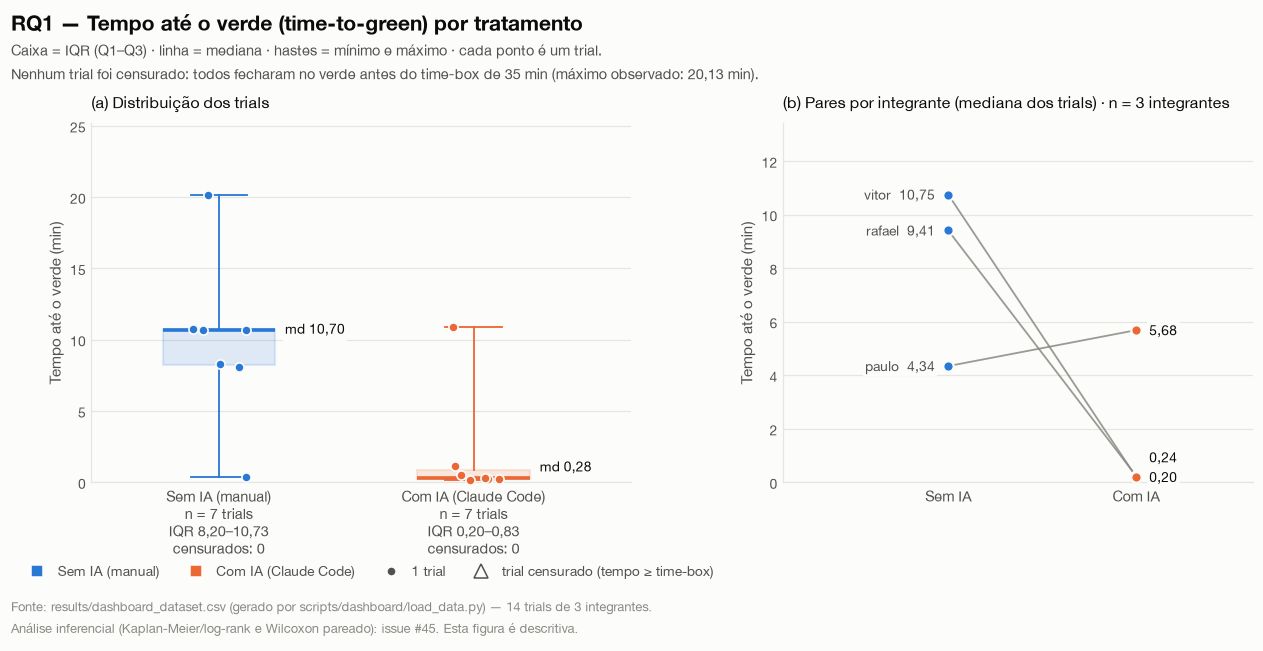

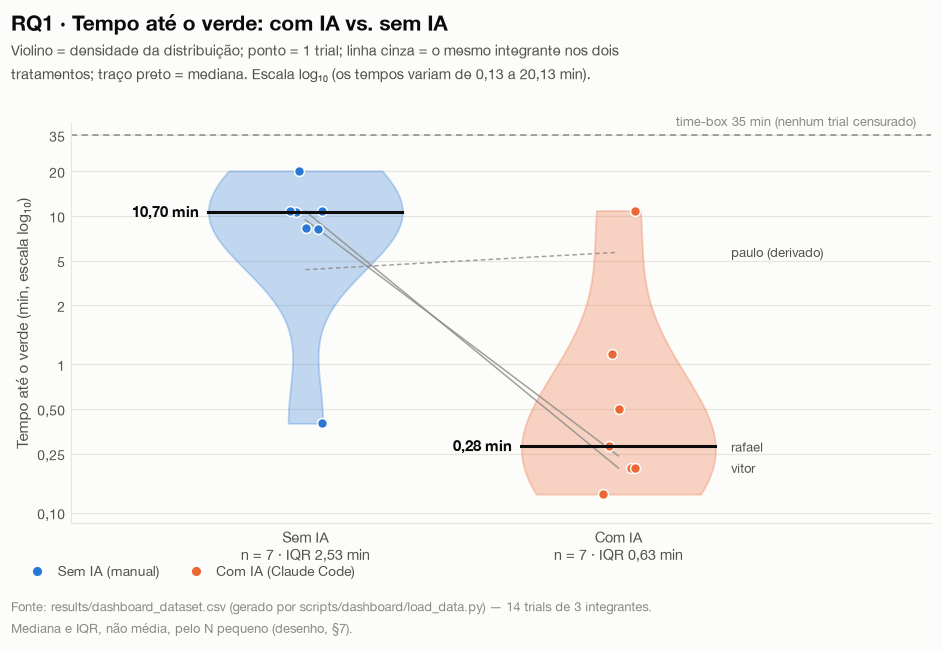

In [6]:
# RQ1 - duas figuras: o boxplot/pares da issue #49 e o VIOLINO (forma da
# distribuicao, escala log10 - os tempos variam duas ordens de grandeza).
fig_rq1 = figure_rq1(df)
save_figure(fig_rq1, FIG_DIR / "rq1_time_to_green.png")

fig_rq1_violino = figure_rq1_violin(df)
save_figure(fig_rq1_violino, FIG_DIR / "rq1_violino_tempo.png")

# Teste de RQ1 (issue #45, docs/analise-rq1.md): Wilcoxon pareado por integrante.
# Nao ha censurados nesta amostra, entao o Kaplan-Meier/log-rank previsto no
# desenho (§7) para o caso com censura nao se aplica -- os quartis sao os
# percentis lineares usuais, e o script registra isso em `metodo`.
rq1 = resultados("rq1")
print(f"trials no plano: {rq1['n_core']} | elegiveis (tempo cronometrado): {rq1['n_eligible']} "
      f"| descartados por tempo derivado: {rq1['n_unverified']}")
for tratamento, d in rq1["descritivos"].items():
    print(f"  {tratamento:<7} n={d['n']} censurados={d['censurados']} "
          f"mediana={d['mediana']:.4f} min  IQR={d['iqr']:.4f}  ({d['metodo']})")
print("pares (mediana por integrante):")
for par in rq1["pares"]:
    print(f"  {par['integrante']:<7} com IA={par['ia_min']:.4f}  sem IA={par['manual_min']:.4f}  "
          f"diferenca={par['diferenca_ia_menos_manual']:+.4f} min")
w = rq1["wilcoxon"]
print(f"Wilcoxon exato bicaudal: W={w['W']}, n={w['n_pares']} pares, p={w['p']:.3f}, "
      f"r_rb={w['r_rank_biserial']:+.3f} -> "
      f"{'rejeitar' if w['p'] < 0.05 else 'NAO rejeitar'} H1_0 a alfa=0,05")
print("omitidos do teste:", rq1["omitidos_wilcoxon"])

## 3. RQ2 — Defeitos / taxa de sucesso

- **Primário:** taxa de sucesso (proporção de trials que atingem o verde dentro
  do time-box) — binária pareada, **McNemar** (issue #46).
- **Secundário:** `pct_tests_passing`, que por construção só varia entre os
  trials censurados (ver o alerta de operacionalização no desenho, §3).

In [7]:
display(success_rate_by_treatment(df))
display(build_participant_summary(df)[["participant", "treatment", "n_trials",
                                        "n_success", "n_censored", "success_rate",
                                        "pct_tests_passing"]])

,treatment,n_trials,n_timed,n_success,n_censored,n_outcome,success_rate
0,manual,7,7,5,0,5,1.0
1,ai,7,7,5,0,5,1.0


,participant,treatment,n_trials,n_success,n_censored,success_rate,pct_tests_passing
0,paulo,manual,2,0,0,NaN,100.0
1,paulo,ai,2,0,0,NaN,100.0
2,rafael,manual,2,2,0,1.0,100.0
3,rafael,ai,2,2,0,1.0,100.0
4,vitor,manual,3,3,0,1.0,100.0
5,vitor,ai,3,3,0,1.0,100.0


planejados: 12 | verificados no trial: 8 | conferidos depois: 4
  com IA  n=4 mediana=100.0% IQR=0.0 p.p.  falhas somadas=0
  sem IA  n=4 mediana=100.0% IQR=0.0 p.p.  falhas somadas=0
Wilcoxon: W=0.0, n=2 pares, p=1.000, diferencas nao nulas=0 -> nao_rejeitar_H0
  ATENCAO: teste DEGENERADO. Todas as diferencas pareadas sao zero, logo esse p
  e uma convencao, nao estimativa de ausencia de efeito. O McNemar primario
  previsto no desenho (§7) tambem nao tem par discordante para detectar efeito:
  por construcao, um trial so fecha como verde com 100% dos testes passando.


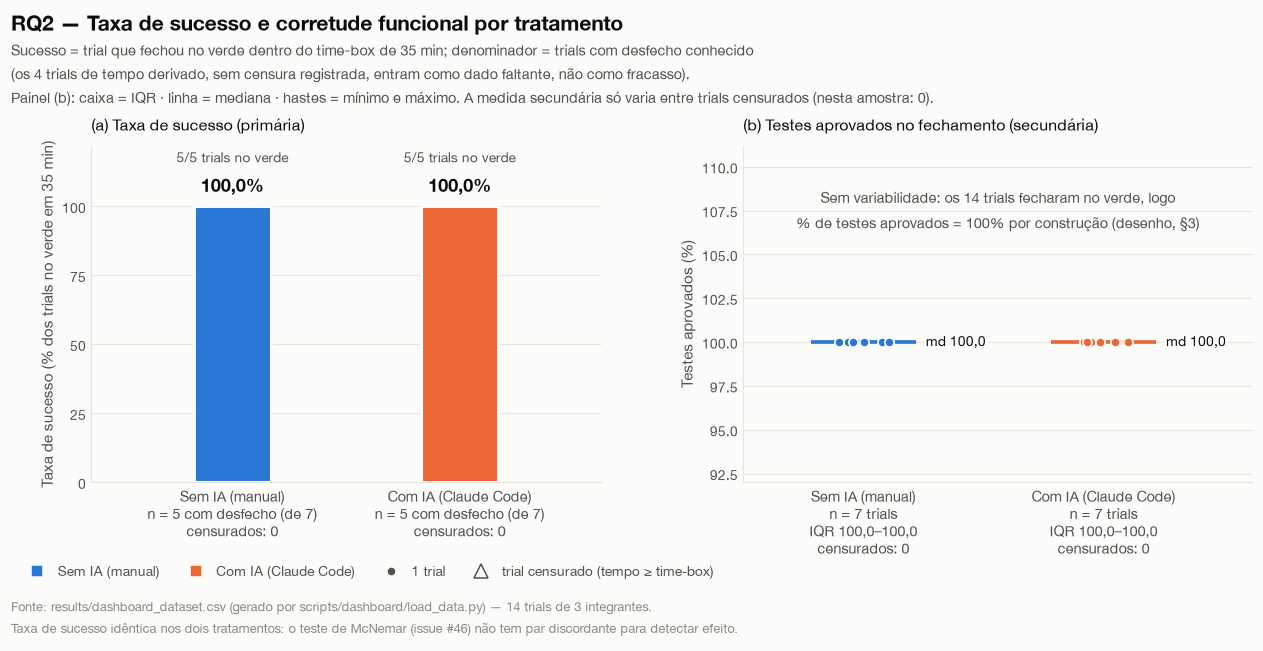

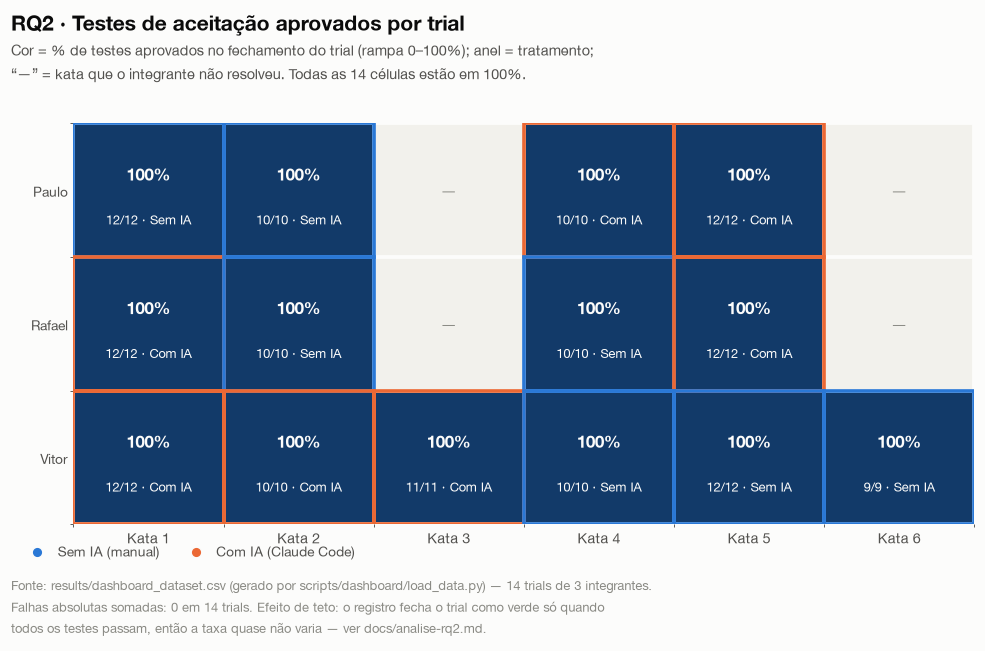

In [8]:
# RQ2 - duas figuras: as barras da taxa de sucesso (issue #49) e o HEATMAP da
# matriz integrante x kata, que mostra o teto de 100% e a cobertura do desenho.
fig_rq2 = figure_rq2(df)
save_figure(fig_rq2, FIG_DIR / "rq2_taxa_sucesso.png")

fig_rq2_heatmap = figure_rq2_heatmap(df)
save_figure(fig_rq2_heatmap, FIG_DIR / "rq2_heatmap_testes.png")

# Teste de RQ2 (issue #46, docs/analise-rq2.md).
rq2 = resultados("rq2")
print(f"planejados: {rq2['n_planejados']} | verificados no trial: {rq2['n_verificados_no_trial']} "
      f"| conferidos depois: {rq2['n_conferidos_posteriormente']}")
for tratamento, d in rq2["descritivos_verificados"].items():
    print(f"  {tratamento:<7} n={d['n_trials']} mediana={d['mediana_pct']:.1f}% "
          f"IQR={d['iqr_pontos_percentuais']:.1f} p.p.  falhas somadas={d['falhas_absolutas_soma']}")
w2 = rq2["wilcoxon"]
print(f"Wilcoxon: W={w2['W']}, n={w2['n_pares']} pares, p={w2['p']:.3f}, "
      f"diferencas nao nulas={w2['n_diferencas_nao_nulas']} -> {w2['decisao_alpha_0_05']}")
if w2.get("resultado_degenerado"):
    print("  ATENCAO: teste DEGENERADO. Todas as diferencas pareadas sao zero, logo esse p")
    print("  e uma convencao, nao estimativa de ausencia de efeito. O McNemar primario")
    print("  previsto no desenho (§7) tambem nao tem par discordante para detectar efeito:")
    print("  por construcao, um trial so fecha como verde com 100% dos testes passando.")

## 4. RQ3 — Qualidade estrutural do código

Família de três hipóteses (correção de Holm-Bonferroni dentro da família):

- **H3a** `cc_avg` — complexidade ciclomática média por função;
- **H3b** `duplication_pct` — percentual de linhas duplicadas;
- **H3c** `loc` — tamanho da solução.

Exploratórias, fora da correção: `cc_total`, `mi_avg`, `sloc`.

In [9]:
display(descriptives_by_treatment(df, ["cc_avg", "duplication_pct", "loc", "sloc",
                                        "cc_total", "mi_avg"]))
display(build_paired_frame(df))

,treatment,metric,n,median,q1,q3,iqr,min,max,mean,std
0,manual,cc_avg,7,3.60,2.625,6.5,3.875,2.00,8.00,4.550000,2.410221
1,manual,duplication_pct,7,0.00,0.000,0.0,0.000,0.00,0.00,0.000000,0.000000
2,manual,loc,7,34.00,30.500,37.0,6.500,17.00,72.00,36.857143,16.984587
3,manual,sloc,7,27.00,23.500,30.5,7.000,11.00,40.00,26.571429,9.034326
4,manual,cc_total,7,8.00,6.500,10.5,4.000,4.00,18.00,9.142857,4.561746
5,manual,mi_avg,7,73.19,65.725,77.7,11.975,47.31,89.24,70.941429,13.294414
6,ai,cc_avg,7,2.60,2.500,5.0,2.500,2.50,13.00,4.728571,3.999881
7,ai,duplication_pct,7,0.00,0.000,0.0,0.000,0.00,0.00,0.000000,0.000000
8,ai,loc,7,43.00,21.000,61.5,40.500,17.00,74.00,42.714286,23.485558
9,ai,sloc,7,17.00,17.000,27.5,10.500,14.00,35.00,22.142857,8.454359


,participant,time_to_green_min_manual,time_to_green_min_ai,time_to_green_min_diff,pct_tests_passing_manual,pct_tests_passing_ai,pct_tests_passing_diff,cc_avg_manual,cc_avg_ai,cc_avg_diff,duplication_pct_manual,duplication_pct_ai,duplication_pct_diff,loc_manual,loc_ai,loc_diff,sloc_manual,sloc_ai,sloc_diff,cc_total_manual,cc_total_ai,cc_total_diff,mi_avg_manual,mi_avg_ai,mi_avg_diff,n_trials_manual,n_trials_ai,n_timed_manual,n_timed_ai,n_success_manual,n_success_ai,n_censored_manual,n_censored_ai,n_outcome_manual,n_outcome_ai,success_rate_manual,success_rate_ai,success_rate_diff
0,paulo,4.3417,5.6834,1.3417,100.0,100.0,0.0,5.3,2.5,-2.8,0.0,0.0,0.0,35.5,69.0,33.5,29.0,19.5,-9.5,12.5,7.5,-5.0,60.25,71.775,11.525,2,2,2,2,0,0,0,0,0,0,NaN,NaN,NaN
1,rafael,9.4083,0.2416,-9.1667,100.0,100.0,0.0,5.0,2.55,-2.45,0.0,0.0,0.0,25.0,41.0,16.0,19.5,26.0,6.5,6.0,11.5,5.5,76.09,63.59,-12.5,2,2,2,2,2,2,0,0,2,2,1.0,1.0,0.0
2,vitor,10.75,0.2,-10.55,100.0,100.0,0.0,2.75,7.0,4.25,0.0,0.0,0.0,37.0,19.0,-18.0,27.0,17.0,-10.0,10.0,13.0,3.0,77.06,58.82,-18.24,3,3,3,3,3,3,0,0,3,3,1.0,1.0,0.0


14 trials de 3 participantes; familia primaria: cc_avg, duplication_pct, loc


,metrica,rotulo,mediana_manual,iqr_manual,mediana_ai,iqr_ai,W,p,r_rb,p_holm,obs
0,cc_avg,CC media por funcao,3.6000,3.8750,2.6000,2.5000,3.0,1.00,0.0000,1.0,
1,cc_per_100_loc,CC total / 100 LOC,23.5294,4.6263,34.8837,24.5537,3.0,1.00,0.0000,NaN,
2,duplication_pct,Linhas duplicadas (%),0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,nao aplicavel: diferencas nulas ou pares insuf...
3,loc,LOC,34.0000,6.5000,43.0000,40.5000,2.0,0.75,0.3333,1.0,
4,mi_avg,MI (exploratorio),73.1900,11.9750,61.5600,10.4650,1.0,0.50,-0.6667,NaN,


Nenhuma das hipoteses primarias sobrevive a Holm (p ajustado = 1,000 em cc_avg e loc);
duplication_pct e 0% nos 14 trials, logo o Wilcoxon nao tem diferenca a ordenar.
Acoplamento declarado no desenho (§8): duplication_pct e sensivel ao tamanho do
arquivo, o que liga H3b a H3c -- e por isso a densidade de CC entra como controle.


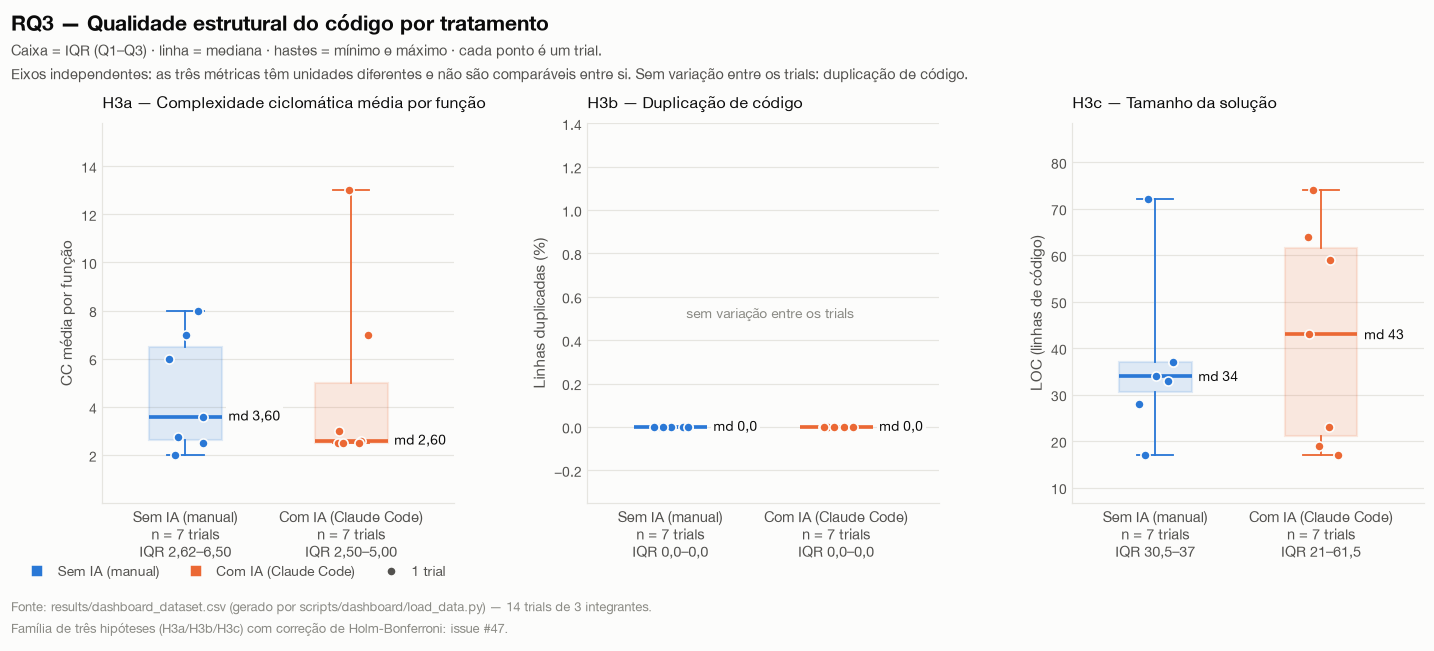

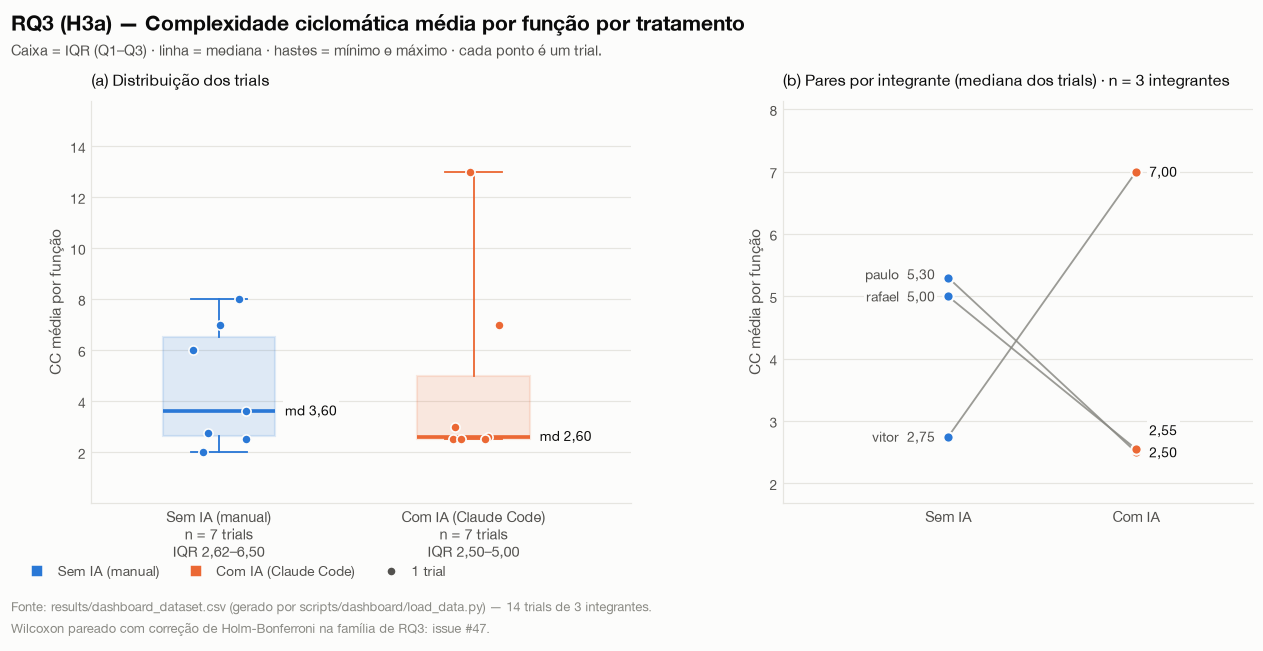

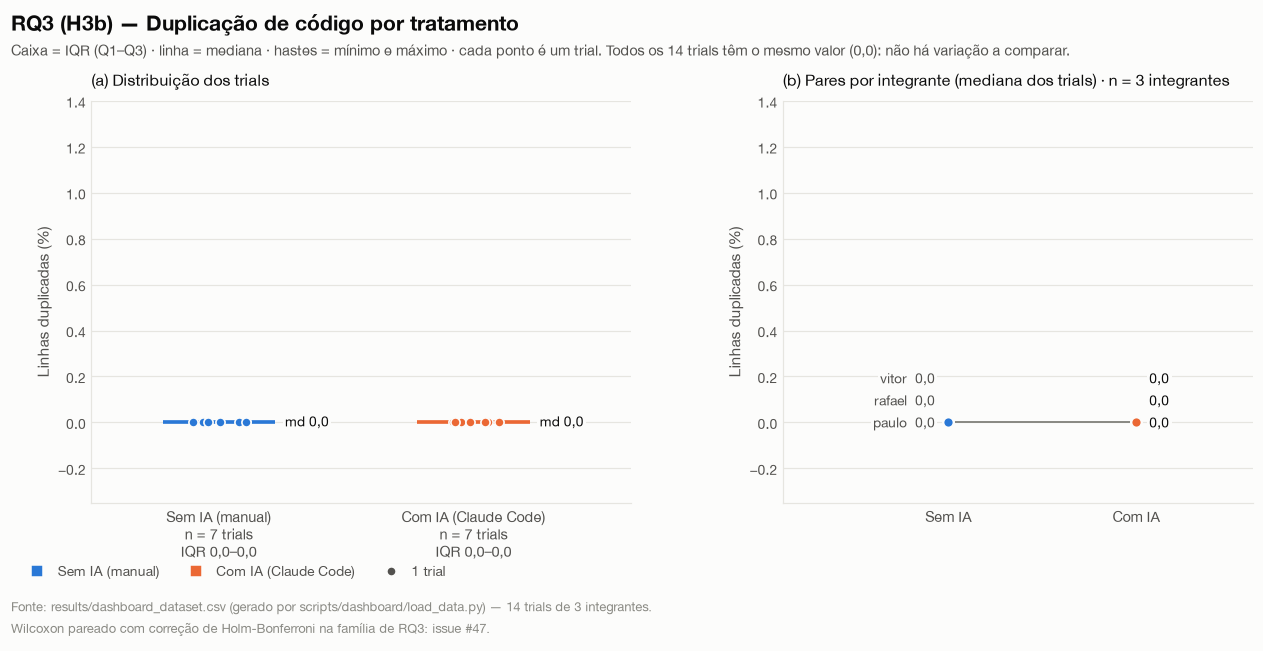

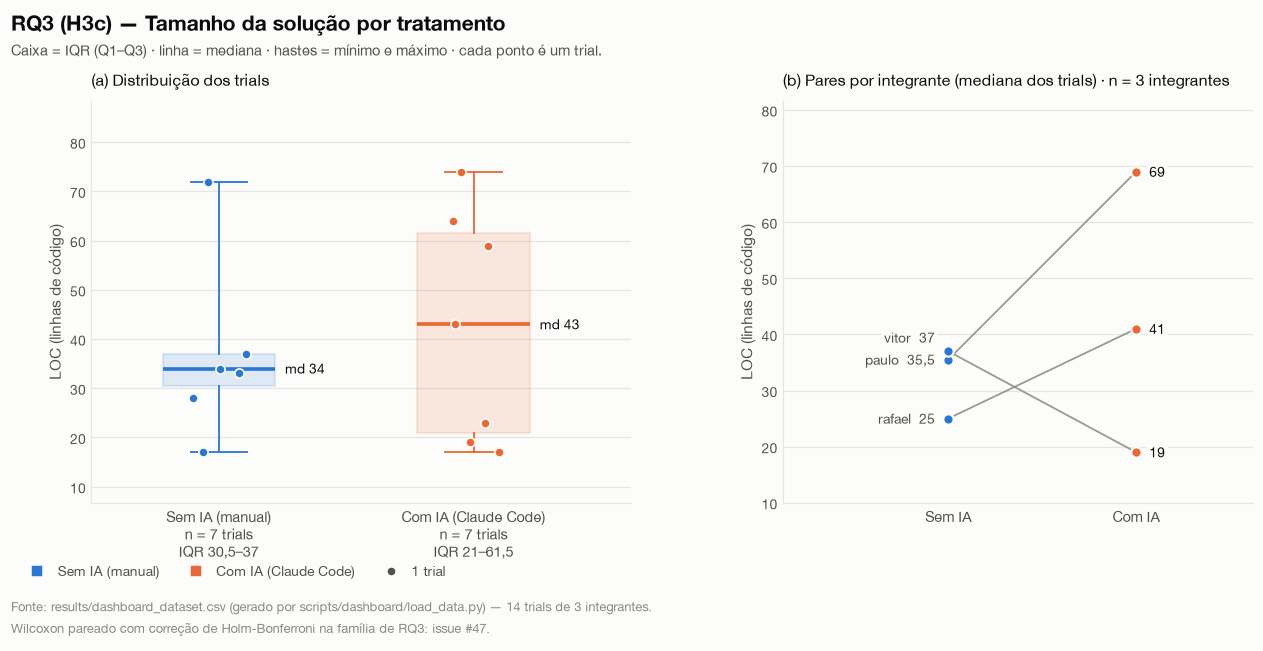

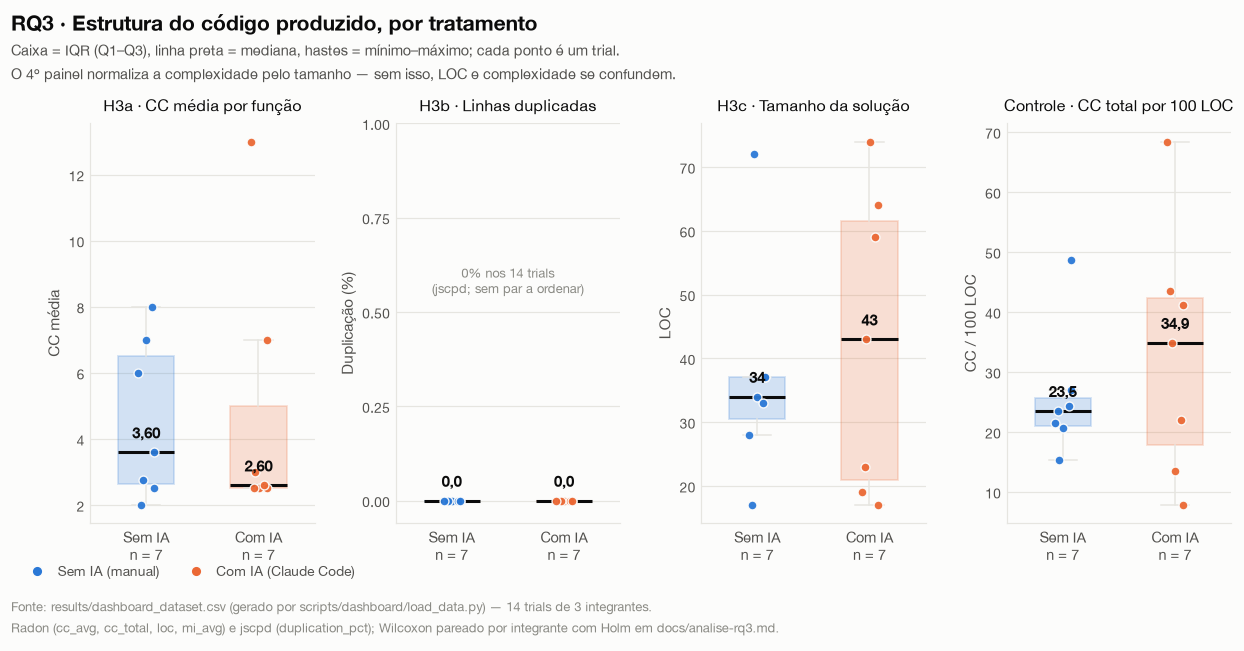

In [10]:
# RQ3 - o painel e as figuras por metrica da issue #49, mais o BOX PLOT das
# quatro metricas (as tres hipoteses + a densidade, que normaliza por LOC).
fig_rq3 = figure_rq3_overview(df)
save_figure(fig_rq3, FIG_DIR / "rq3_estrutura.png")

for metrica in RQ3_METRICS:
    save_figure(figure_rq3_metric(df, metrica), FIG_DIR / f"rq3_{metrica}.png")

fig_rq3_box = figure_rq3_box(df)
save_figure(fig_rq3_box, FIG_DIR / "rq3_boxplot_estrutura.png")

# Testes de RQ3 (issue #47, docs/analise-rq3.md): Wilcoxon pareado por
# participante em cada metrica + Holm na familia primaria (H3a, H3b, H3c).
rq3 = resultados("rq3")
print(f"{rq3['n_trials']} trials de {rq3['n_participantes']} participantes; "
      f"familia primaria: {', '.join(rq3['familia_primaria'])}")
linhas = []
for metrica, e in rq3["metricas"].items():
    w3 = e["wilcoxon"]
    linhas.append({
        "metrica": metrica,
        "rotulo": e["rotulo"],
        "mediana_manual": e["descritivos"]["manual"]["mediana"],
        "iqr_manual": e["descritivos"]["manual"]["iqr"],
        "mediana_ai": e["descritivos"]["ai"]["mediana"],
        "iqr_ai": e["descritivos"]["ai"]["iqr"],
        "W": w3["W"] if w3 else None,
        "p": w3["p"] if w3 else None,
        "r_rb": w3["r_rank_biserial"] if w3 else None,
        "p_holm": rq3["holm_primario"].get(metrica),
        "obs": e.get("wilcoxon_obs", ""),
    })
display(pd.DataFrame(linhas))
print("Nenhuma das hipoteses primarias sobrevive a Holm (p ajustado = 1,000 em cc_avg e loc);")
print("duplication_pct e 0% nos 14 trials, logo o Wilcoxon nao tem diferenca a ordenar.")
print("Acoplamento declarado no desenho (§8): duplication_pct e sensivel ao tamanho do")
print("arquivo, o que liga H3b a H3c -- e por isso a densidade de CC entra como controle.")

## 5. RQ4 — O ganho de velocidade cobra um preço estrutural? *(RQ extra)*

- **H4₀:** `ρ(time_to_green_min, M) = 0` para cada `M` ∈ {`loc`, `cc_avg`,
  `cc_total`, `densidade_cc`, `mi_avg`} (bicaudal, α = 0,05).
- Família de 5 hipóteses → **Holm-Bonferroni**.
- **r de Pearson** (linear, com IC 95% por *z* de Fisher) e **ρ de Spearman**
  (monotônico, robusto), reportados global **e dentro de cada tratamento**.
- Gráfico: **dispersão com reta de ajuste** — o tipo próprio para relação entre
  duas medidas numéricas.

Detalhes e discussão do confundimento: [`docs/analise-rq4.md`](../../docs/analise-rq4.md).

10 trials cronometrados no primario; 4 excluidos por tempo derivado: paulo/kata1 (sem IA), paulo/kata2 (sem IA), paulo/kata4 (com IA), paulo/kata5 (com IA)

Primario (10 trials cronometrados) - tempo x estrutura:


,metrica,n,pearson_r,p,p_holm,ic95,spearman_rho,p_spearman,r2
0,mi_medio,10,0.7148,0.0202,0.1010,[+0.15; +0.93],0.7234,0.0180,0.5109
1,densidade_cc,10,-0.6754,0.0321,0.1284,[-0.92; -0.08],-0.7295,0.0166,0.4561
2,loc,10,0.4328,0.2116,0.6348,[-0.27; +0.83],0.3689,0.2942,0.1873
3,cc_total,10,-0.3641,0.3010,0.6348,[-0.81; +0.34],-0.3700,0.2926,0.1326
4,cc_media,10,-0.3033,0.3943,0.6348,[-0.78; +0.40],-0.3476,0.3251,0.0920



So com IA (n = 5):


,metrica,n,pearson_r,p,p_holm,ic95,spearman_rho,p_spearman,r2
0,mi_medio,5,-0.8284,0.0831,None,[-0.99; +0.20],-0.3591,0.5528,0.6862
1,cc_total,5,0.5634,0.3226,None,[-0.63; +0.97],0.2895,0.6366,0.3174
2,cc_media,5,-0.4179,0.4838,None,[-0.95; +0.74],-0.6156,0.2690,0.1747
3,loc,5,0.3343,0.5825,None,[-0.78; +0.94],0.4104,0.4925,0.1117
4,densidade_cc,5,-0.2895,0.6366,None,[-0.93; +0.80],-0.4104,0.4925,0.0838



So sem IA (n = 5):


,metrica,n,pearson_r,p,p_holm,ic95,spearman_rho,p_spearman,r2
0,loc,5,0.8762,0.0513,None,[-0.03; +0.99],0.5,0.3910,0.7677
1,densidade_cc,5,-0.8709,0.0546,None,[-0.99; +0.05],-0.7,0.1881,0.7585
2,cc_total,5,0.5573,0.3291,None,[-0.64; +0.97],0.5,0.3910,0.3106
3,cc_media,5,-0.4887,0.4035,None,[-0.96; +0.69],-0.1,0.8729,0.2388
4,mi_medio,5,0.3273,0.5909,None,[-0.78; +0.94],0.4,0.5046,0.1071



Sensibilidade (14 trials, inclui tempos derivados):


,metrica,n,pearson_r,p,p_holm,ic95,spearman_rho,p_spearman,r2
0,mi_medio,14,0.6729,0.0084,0.0420,[+0.22; +0.89],0.6975,0.0056,0.4528
1,densidade_cc,14,-0.5943,0.0250,0.1000,[-0.86; -0.09],-0.6689,0.0089,0.3531
2,cc_total,14,-0.4747,0.0863,0.2589,[-0.80; +0.07],-0.4718,0.0885,0.2253
3,loc,14,0.2565,0.3761,0.7522,[-0.32; +0.69],0.3385,0.2365,0.0658
4,cc_media,14,-0.2064,0.4790,0.7522,[-0.66; +0.36],-0.3308,0.2481,0.0426


PosixPath('/Users/rafaelfranco/Documents/Repositorys/Lab02AssistentesdeIAxCodManual/results/figures/rq4_dispersao_pearson.png')

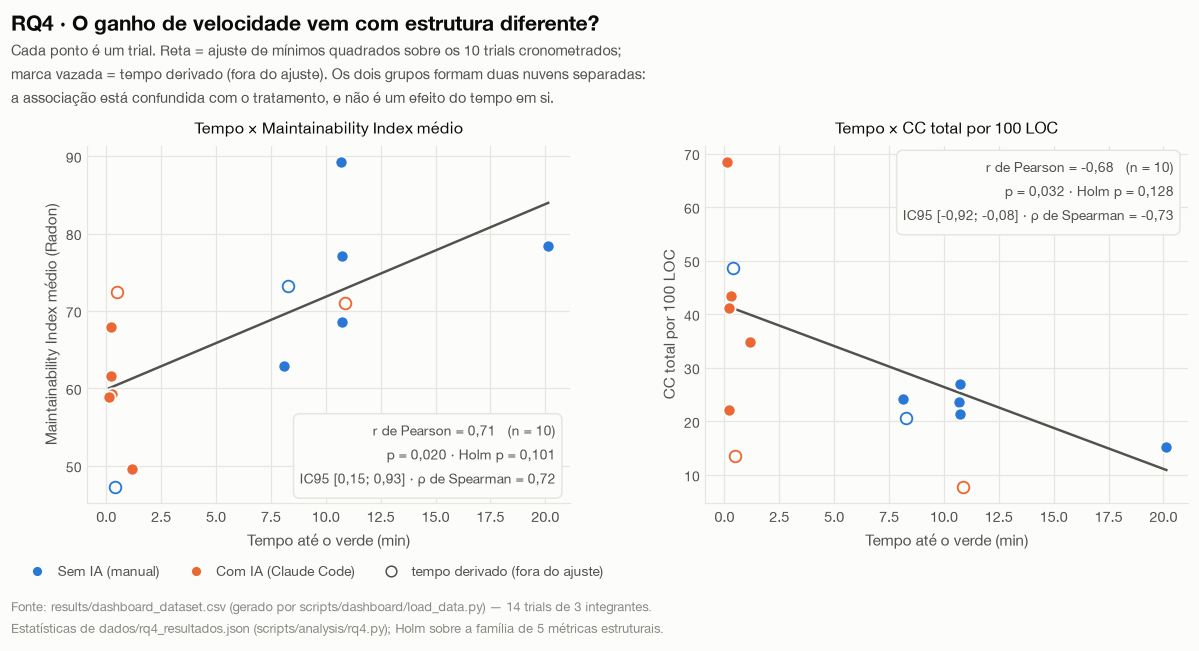

In [11]:
rq4 = resultados("rq4")
print(f"{rq4['n_primario_cronometrado']} trials cronometrados no primario; "
      f"{rq4['n_excluidos_tempo_derivado']} excluidos por tempo derivado: "
      f"{', '.join(rq4['excluidos'])}")

def tabela_rq4(bloco, holm=None):
    linhas = []
    for metrica, s in bloco.items():
        ic = s.get("ic95_pearson")
        linhas.append({
            "metrica": metrica, "n": s["n"],
            "pearson_r": s["pearson_r"], "p": s["pearson_p"],
            "p_holm": (holm or {}).get(metrica),
            "ic95": f"[{ic[0]:+.2f}; {ic[1]:+.2f}]" if ic else None,
            "spearman_rho": s["spearman_rho"], "p_spearman": s["spearman_p"],
            "r2": s.get("r2"),
        })
    return pd.DataFrame(linhas).sort_values("p").reset_index(drop=True)

print("\nPrimario (10 trials cronometrados) - tempo x estrutura:")
display(tabela_rq4(rq4["primario"]["global"], rq4["primario"]["holm_global"]["pearson"]))

# A estratificacao e o ponto da analise: se a correlacao global sobrevive dentro
# de cada tratamento, ela e do tempo; se desaparece, era o tratamento disfarcado.
for tratamento, bloco in rq4["primario"]["por_tratamento"].items():
    print(f"\nSo {tratamento} (n = {bloco['n_trials']}):")
    display(tabela_rq4({k: v for k, v in bloco.items() if k != "n_trials"}))

print("\nSensibilidade (14 trials, inclui tempos derivados):")
display(tabela_rq4(rq4["sensibilidade_com_derivados"]["global"],
                   rq4["sensibilidade_com_derivados"]["holm_global"]["pearson"]))

fig_rq4 = figure_rq4_scatter(df, rq4)
save_figure(fig_rq4, FIG_DIR / "rq4_dispersao_pearson.png")

## 6. RQ5 — O efeito da IA é o mesmo em toda kata? *(diferencial do grupo)*

Muda a **unidade de agregação**: a kata, não o integrante.

- `speedup = mediana(tempo sem IA) ÷ mediana(tempo com IA)` — em vezes;
- `ganho_min` — a mesma diferença em minutos (41× em uma kata curta pode valer
  menos, na prática, que 1,4× em uma longa);
- `dificuldade = mediana(tempo sem IA)` da kata.

- **H5₀:** speedup igual em todas as katas e sem associação com a dificuldade.
- **Exploratória:** sem pares "mesma pessoa, mesma kata", o contraste por kata é
  **entre pessoas** — habilidade e tratamento não se separam aqui.
- Gráfico: **bolhas** (3 dimensões: dificuldade × speedup × nº de testes, cor =
  razão de LOC).

Detalhes: [`docs/analise-rq5.md`](../../docs/analise-rq5.md).

PRIMARIO - 12 trials do plano de 4 katas (inclui os tempos derivados de Paulo)


,kata,rotulo,testes_total,tempo_mediano_sem_ia,tempo_mediano_com_ia,speedup,ganho_min,razao_loc_ia_sobre_manual,usa_tempo_derivado,integrantes_sem_ia,integrantes_com_ia
0,kata1,Cesta de Compras,12,0.4000,0.6834,0.5854,-0.2833,1.3784,True,[paulo],"[rafael, vitor]"
1,kata2,Escala de Plantoes,10,8.2000,0.2000,41.0000,8.0000,0.5075,True,"[paulo, rafael]",[vitor]
2,kata4,Extrator de Tags,10,15.4166,10.8667,1.4187,4.5499,1.4382,True,"[rafael, vitor]",[paulo]
3,kata5,Controle de Estoque,12,10.7167,0.3916,27.3630,10.3250,1.3108,True,[vitor],"[paulo, rafael]"


speedup: mediana 14.3909x | faixa 0.5854x-41.0x | razao max/min 70.0376x | katas em que a IA foi mais lenta: ['kata1']
Spearman(dificuldade, speedup): rho=0.2, p=0.8, n=4 -> NAO rejeitar H5_0
Com n = 4 katas, o menor p bicaudal possivel no Spearman exato e 0,083: o teste nao
poderia dar significativo nem com ordenacao perfeita. Numero reportado por transparencia.

Katas sem contraste (so um tratamento): nenhuma

SENSIBILIDADE - apenas trials com tempo cronometrado (exclui os 4 derivados)


,kata,rotulo,testes_total,tempo_mediano_sem_ia,tempo_mediano_com_ia,speedup,ganho_min,razao_loc_ia_sobre_manual,usa_tempo_derivado,integrantes_sem_ia,integrantes_com_ia
0,kata2,Escala de Plantoes,10,8.1167,0.2000,40.5835,7.9167,0.5152,False,[rafael],[vitor]
1,kata5,Controle de Estoque,12,10.7167,0.2833,37.8281,10.4334,0.6216,False,[vitor],[rafael]


speedup: faixa 37.8281x-40.5835x | razao max/min 1.0728x em 2 katas
=> a dispersao de 70x do primario vem dos tempos DERIVADOS, nao do tipo de tarefa.


PosixPath('/Users/rafaelfranco/Documents/Repositorys/Lab02AssistentesdeIAxCodManual/results/figures/rq5_bolhas_speedup.png')

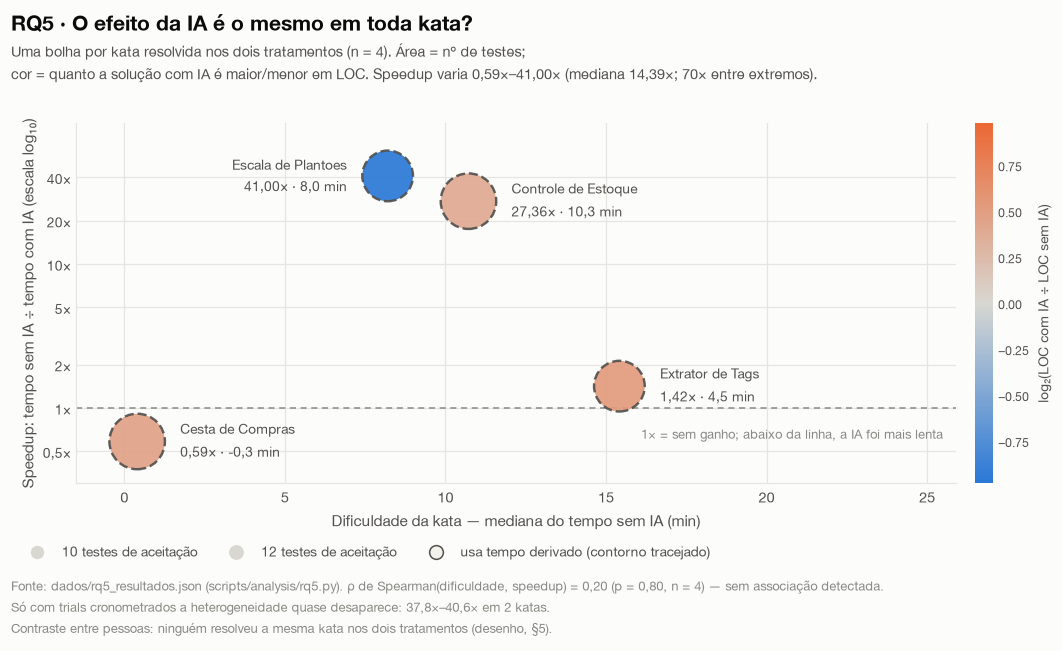

In [12]:
rq5 = resultados("rq5")

colunas = ["kata", "rotulo", "testes_total", "tempo_mediano_sem_ia", "tempo_mediano_com_ia",
           "speedup", "ganho_min", "razao_loc_ia_sobre_manual", "usa_tempo_derivado",
           "integrantes_sem_ia", "integrantes_com_ia"]
print(f"PRIMARIO - {rq5['primario']['conjunto']}")
display(pd.DataFrame(rq5["primario"]["katas"])[colunas])
het = rq5["primario"]["heterogeneidade"]
print(f"speedup: mediana {het['speedup_mediana']}x | faixa {het['speedup_min']}x-{het['speedup_max']}x "
      f"| razao max/min {het['razao_max_min']}x | katas em que a IA foi mais lenta: "
      f"{het['katas_com_ia_mais_lenta'] or 'nenhuma'}")
sp = het["spearman_dificuldade_x_speedup"]
print(f"Spearman(dificuldade, speedup): rho={sp['rho']}, p={sp['p']}, n={sp['n']} "
      f"-> {'rejeitar' if (sp['p'] or 1) < 0.05 else 'NAO rejeitar'} H5_0")
print("Com n = 4 katas, o menor p bicaudal possivel no Spearman exato e 0,083: o teste nao")
print("poderia dar significativo nem com ordenacao perfeita. Numero reportado por transparencia.")
print("\nKatas sem contraste (so um tratamento):",
      [k["kata"] for k in rq5["primario"]["katas_sem_contraste"]] or "nenhuma")

sens = rq5["sensibilidade_so_cronometrados"]
print(f"\nSENSIBILIDADE - {sens['conjunto']}")
display(pd.DataFrame(sens["katas"])[colunas])
hs = sens["heterogeneidade"]
print(f"speedup: faixa {hs['speedup_min']}x-{hs['speedup_max']}x | razao max/min {hs['razao_max_min']}x "
      f"em {hs['n_katas']} katas")
print("=> a dispersao de 70x do primario vem dos tempos DERIVADOS, nao do tipo de tarefa.")

fig_rq5 = figure_rq5_bubbles(rq5)
save_figure(fig_rq5, FIG_DIR / "rq5_bolhas_speedup.png")

## 7. Síntese para o Relatório Final (issue #50)

Uma linha por RQ: medida por tratamento, teste, `p`, tamanho de efeito e a
leitura. Todos os números vêm dos JSON de `dados/`, os mesmos que o
[Relatório Final](../../docs/RELATORIO_FINAL.md) cita — nada é digitado aqui.

**Aviso de poder estatístico que acompanha toda linha desta tabela:** com 3
integrantes e 14 trials, o estudo é subdimensionado. "Não rejeitar H₀" significa
*não detectamos diferença*, nunca *não há diferença* (desenho, §7).

In [13]:
rq1_d, rq2_d = rq1["descritivos"], rq2["descritivos_verificados"]
cc = rq3["metricas"]["cc_avg"]["descritivos"]
loc = rq3["metricas"]["loc"]["descritivos"]
mi4 = rq4["primario"]["global"]["mi_medio"]
dens4 = rq4["primario"]["global"]["densidade_cc"]
het5 = rq5["primario"]["heterogeneidade"]

sintese = pd.DataFrame([
    {"RQ": "RQ1 tempo", "gráfico": "violino",
     "sem IA": f"mediana {rq1_d['sem IA']['mediana']:.2f} min (IQR {rq1_d['sem IA']['iqr']:.2f})",
     "com IA": f"mediana {rq1_d['com IA']['mediana']:.2f} min (IQR {rq1_d['com IA']['iqr']:.2f})",
     "teste": f"Wilcoxon pareado, n={rq1['wilcoxon']['n_pares']}",
     "p": rq1["wilcoxon"]["p"], "efeito": f"r_rb={rq1['wilcoxon']['r_rank_biserial']:+.2f}",
     "leitura": "IA mais rápida nos 2 pares, mas n=2 não sustenta conclusão: não rejeitar H1_0"},
    {"RQ": "RQ2 defeitos", "gráfico": "heatmap",
     "sem IA": f"{rq2_d['sem IA']['mediana_pct']:.0f}% aprovados, {rq2_d['sem IA']['falhas_absolutas_soma']} falhas",
     "com IA": f"{rq2_d['com IA']['mediana_pct']:.0f}% aprovados, {rq2_d['com IA']['falhas_absolutas_soma']} falhas",
     "teste": "Wilcoxon degenerado / McNemar sem par discordante",
     "p": rq2["wilcoxon"]["p"], "efeito": "indefinido",
     "leitura": "efeito de teto: todo trial verde tem 100%; a métrica não discrimina"},
    {"RQ": "RQ3a complexidade", "gráfico": "box plot",
     "sem IA": f"CC média {cc['manual']['mediana']:.2f} (IQR {cc['manual']['iqr']:.2f})",
     "com IA": f"CC média {cc['ai']['mediana']:.2f} (IQR {cc['ai']['iqr']:.2f})",
     "teste": f"Wilcoxon pareado, n={rq3['metricas']['cc_avg']['wilcoxon']['n_pares']} + Holm",
     "p": rq3["holm_primario"].get("cc_avg"), "efeito": f"r_rb={rq3['metricas']['cc_avg']['wilcoxon']['r_rank_biserial']:+.2f}",
     "leitura": "mediana menor com IA, mas p(Holm)=1,00 e direções individuais divergem"},
    {"RQ": "RQ3c tamanho", "gráfico": "box plot",
     "sem IA": f"LOC {loc['manual']['mediana']:.0f} (IQR {loc['manual']['iqr']:.0f})",
     "com IA": f"LOC {loc['ai']['mediana']:.0f} (IQR {loc['ai']['iqr']:.0f})",
     "teste": f"Wilcoxon pareado, n={rq3['metricas']['loc']['wilcoxon']['n_pares']} + Holm",
     "p": rq3["holm_primario"].get("loc"), "efeito": f"r_rb={rq3['metricas']['loc']['wilcoxon']['r_rank_biserial']:+.2f}",
     "leitura": "duplicação 0% nos 14 trials (H3b sem par a ordenar); LOC sem diferença detectada"},
    {"RQ": "RQ4 tempo × estrutura", "gráfico": "dispersão + Pearson",
     "sem IA": f"r(tempo, MI)={rq4['primario']['por_tratamento']['sem IA']['mi_medio']['pearson_r']:+.2f} intra-tratamento",
     "com IA": f"r(tempo, MI)={rq4['primario']['por_tratamento']['com IA']['mi_medio']['pearson_r']:+.2f} intra-tratamento",
     "teste": f"Pearson/Spearman, n={mi4['n']} + Holm (família de 5)",
     "p": rq4["primario"]["holm_global"]["pearson"]["mi_medio"],
     "efeito": f"r={mi4['pearson_r']:+.2f} (MI), {dens4['pearson_r']:+.2f} (densidade)",
     "leitura": "correlação global forte NÃO sobrevive a Holm e se dissolve intra-tratamento: confundida com o tratamento"},
    {"RQ": "RQ5 efeito por kata", "gráfico": "bolhas",
     "sem IA": f"dificuldade 0,40–15,42 min entre katas",
     "com IA": f"speedup mediano {het5['speedup_mediana']:.2f}x",
     "teste": f"Spearman(dificuldade, speedup), n={het5['spearman_dificuldade_x_speedup']['n']}",
     "p": het5["spearman_dificuldade_x_speedup"]["p"],
     "efeito": f"rho={het5['spearman_dificuldade_x_speedup']['rho']:+.2f}; faixa {het5['speedup_min']:.2f}x–{het5['speedup_max']:.2f}x",
     "leitura": "dispersão de 70x é artefato dos tempos derivados: só com trials cronometrados, 37,8x–40,6x"},
])
display(sintese)

print("\nFiguras exportadas (uma por RQ + as da issue #49), na ordem do relatório:")
for nome in ["rq1_violino_tempo", "rq1_time_to_green", "rq2_heatmap_testes", "rq2_taxa_sucesso",
             "rq3_boxplot_estrutura", "rq3_estrutura", "rq3_cc_avg", "rq3_duplication_pct",
             "rq3_loc", "rq4_dispersao_pearson", "rq5_bolhas_speedup"]:
    caminho = FIG_DIR / f"{nome}.png"
    print(f"  {'OK ' if caminho.exists() else 'FALTA'} {caminho.relative_to(REPO_ROOT)}")

# `export_all(df, FIG_DIR)` regenera as figuras da #49 fora do notebook (o que
# `python scripts/dashboard/plots.py` faz); as cinco por RQ saem de
# `python scripts/dashboard/plots_advanced.py`.

,RQ,gráfico,sem IA,com IA,teste,p,efeito,leitura
0,RQ1 tempo,violino,mediana 10.71 min (IQR 3.02),mediana 0.24 min (IQR 0.30),"Wilcoxon pareado, n=2",0.500,r_rb=-1.00,"IA mais rápida nos 2 pares, mas n=2 não susten..."
1,RQ2 defeitos,heatmap,"100% aprovados, 0 falhas","100% aprovados, 0 falhas",Wilcoxon degenerado / McNemar sem par discordante,1.000,indefinido,efeito de teto: todo trial verde tem 100%; a m...
2,RQ3a complexidade,box plot,CC média 3.60 (IQR 3.88),CC média 2.60 (IQR 2.50),"Wilcoxon pareado, n=3 + Holm",1.000,r_rb=+0.00,"mediana menor com IA, mas p(Holm)=1,00 e direç..."
3,RQ3c tamanho,box plot,LOC 34 (IQR 6),LOC 43 (IQR 40),"Wilcoxon pareado, n=3 + Holm",1.000,r_rb=+0.33,duplicação 0% nos 14 trials (H3b sem par a ord...
4,RQ4 tempo × estrutura,dispersão + Pearson,"r(tempo, MI)=+0.33 intra-tratamento","r(tempo, MI)=-0.83 intra-tratamento","Pearson/Spearman, n=10 + Holm (família de 5)",0.101,"r=+0.71 (MI), -0.68 (densidade)",correlação global forte NÃO sobrevive a Holm e...
5,RQ5 efeito por kata,bolhas,"dificuldade 0,40–15,42 min entre katas",speedup mediano 14.39x,"Spearman(dificuldade, speedup), n=4",0.800,rho=+0.20; faixa 0.59x–41.00x,dispersão de 70x é artefato dos tempos derivad...



Figuras exportadas (uma por RQ + as da issue #49), na ordem do relatório:
  OK  results/figures/rq1_violino_tempo.png
  OK  results/figures/rq1_time_to_green.png
  OK  results/figures/rq2_heatmap_testes.png
  OK  results/figures/rq2_taxa_sucesso.png
  OK  results/figures/rq3_boxplot_estrutura.png
  OK  results/figures/rq3_estrutura.png
  OK  results/figures/rq3_cc_avg.png
  OK  results/figures/rq3_duplication_pct.png
  OK  results/figures/rq3_loc.png
  OK  results/figures/rq4_dispersao_pearson.png
  OK  results/figures/rq5_bolhas_speedup.png
